# Customer Segmentation Analysis

## Project Overview

This project performs customer segmentation using transaction data from an online retail business.

The objective is to understand customer purchasing behaviour and divide customers into meaningful groups using RFM analysis and K-Means clustering.

RFM analysis considers:
- Recency
- Frequency
- Monetary value

The resulting customer segments can help businesses create targeted marketing strategies and improve customer retention.

## Objectives

- Understand the structure of customer transaction data.
- Clean and prepare the dataset for analysis.
- Calculate Recency, Frequency, and Monetary values.
- Calculate average purchase value and customer lifetime value proxy.
- Segment customers using K-Means clustering.
- Use the Elbow Method to determine the suitable number of clusters.
- Visualize customer segments.
- Profile each customer segment.
- Develop marketing strategies for different customer groups.

## Methodology

The project follows these steps:

1. Data loading and inspection
2. Data cleaning
3. Transaction value calculation
4. RFM analysis
5. Behavioral feature selection
6. Feature standardization using StandardScaler
7. Elbow Method for selecting the number of clusters
8. K-Means clustering
9. Customer segment visualization
10. Cluster profiling
11. Business insights and marketing recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [3]:
df = pd.read_excel('Online Retail.xlsx')

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [9]:
df.duplicated().sum()

np.int64(5268)

In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [11]:
df['CustomerID'].nunique()

4372

In [12]:
df['InvoiceNo'].nunique()

25900

In [13]:
df['Country'].nunique()

38

In [14]:
df['Country'].value_counts().head(10)

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [15]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [16]:
df = df.dropna(subset=['CustomerID'])

In [17]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [18]:
df = df[df['Quantity'] > 0]

In [19]:
df = df[df['UnitPrice'] > 0]

In [20]:
df.shape

(397884, 8)

In [21]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [22]:
df.duplicated().sum()

np.int64(5192)

In [23]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [24]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [25]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [26]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].describe()

,Quantity,UnitPrice,TotalAmount
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [27]:
latest_date = df['InvoiceDate'].max()

print("Latest Purchase Date:", latest_date)

Latest Purchase Date: 2011-12-09 12:50:00


In [28]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [29]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [30]:
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

In [31]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [32]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [33]:
rfm['AveragePurchaseValue'] = rfm['Monetary'] / rfm['Frequency']

In [34]:
rfm[['Frequency', 'Monetary', 'AveragePurchaseValue']].head()

,Frequency,Monetary,AveragePurchaseValue
CustomerID,,,
12346.0,1,77183.60,77183.600000
12347.0,7,4310.00,615.714286
12348.0,4,1797.24,449.310000
12349.0,1,1757.55,1757.550000
12350.0,1,334.40,334.400000


In [35]:
rfm['CustomerLifetimeValue'] = rfm['Monetary']

In [36]:
rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
CustomerID,,,,,
12346.0,326,1,77183.60,77183.600000,77183.60
12347.0,2,7,4310.00,615.714286,4310.00
12348.0,75,4,1797.24,449.310000,1797.24
12349.0,19,1,1757.55,1757.550000,1757.55
12350.0,310,1,334.40,334.400000,334.40


In [37]:
rfm.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0
AveragePurchaseValue,0
CustomerLifetimeValue,0


In [38]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

rfm_features.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

In [41]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


In [42]:
rfm_scaled_df.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,1.801745e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.281344e-01
25%,-7.453445e-01,-4.250965e-01,-1.943495e-01
50%,-4.153533e-01,-2.951776e-01,-1.535104e-01
75%,4.946227e-01,9.457903e-02,-4.367134e-02
max,2.814561e+00,2.659803e+01,3.094634e+01


In [43]:
from sklearn.cluster import KMeans

In [44]:
inertia = []

In [45]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

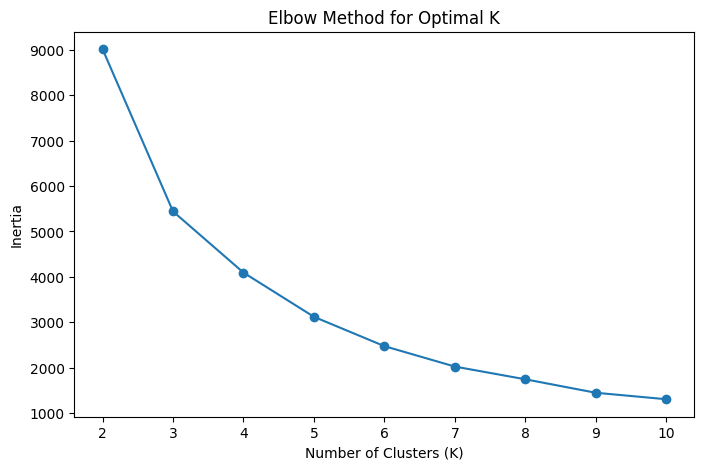

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()

In [47]:
k = 4

In [48]:
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

In [49]:
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

In [50]:
rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue,Cluster
CustomerID,,,,,,
12346.0,326,1,77183.60,77183.600000,77183.60,3
12347.0,2,7,4310.00,615.714286,4310.00,0
12348.0,75,4,1797.24,449.310000,1797.24,0
12349.0,19,1,1757.55,1757.550000,1757.55,0
12350.0,310,1,334.40,334.400000,334.40,1


In [51]:
rfm['Cluster'].value_counts().sort_index()

,count
Cluster,
0,3054
1,1067
2,13
3,204


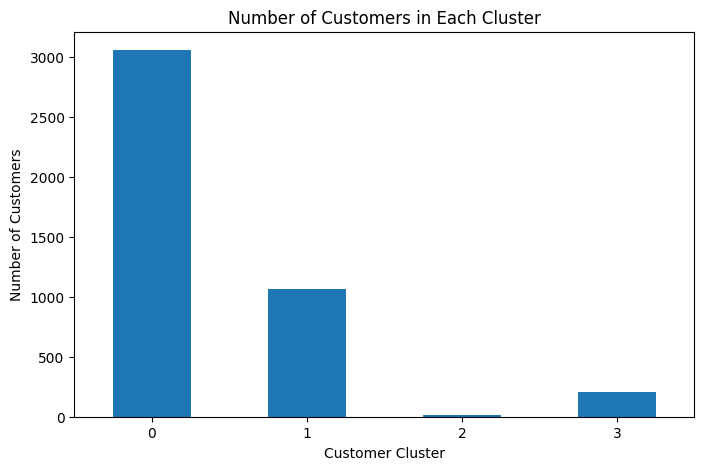

In [52]:
plt.figure(figsize=(8, 5))

rfm['Cluster'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Cluster')
plt.xticks(rotation=0)

plt.show()

In [53]:
cluster_profile = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary',
    'AveragePurchaseValue',
    'CustomerLifetimeValue'
]].mean()

cluster_profile

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
Cluster,,,,,
0,43.702685,3.682711,1359.049284,376.756939,1359.049284
1,248.075914,1.552015,480.617480,314.811424,480.617480
2,7.384615,82.538462,127338.313846,8570.727706,127338.313846
3,15.500000,22.333333,12709.090490,1080.413842,12709.090490


In [54]:
cluster_profile.round(2)

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
Cluster,,,,,
0,43.70,3.68,1359.05,376.76,1359.05
1,248.08,1.55,480.62,314.81,480.62
2,7.38,82.54,127338.31,8570.73,127338.31
3,15.50,22.33,12709.09,1080.41,12709.09


In [55]:
cluster_profile.sort_values('Monetary', ascending=False).round(2)

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
Cluster,,,,,
2,7.38,82.54,127338.31,8570.73,127338.31
3,15.50,22.33,12709.09,1080.41,12709.09
0,43.70,3.68,1359.05,376.76,1359.05
1,248.08,1.55,480.62,314.81,480.62


In [56]:
cluster_profile[['Recency', 'Frequency', 'Monetary']].round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1359.05
1,248.08,1.55,480.62
2,7.38,82.54,127338.31
3,15.50,22.33,12709.09


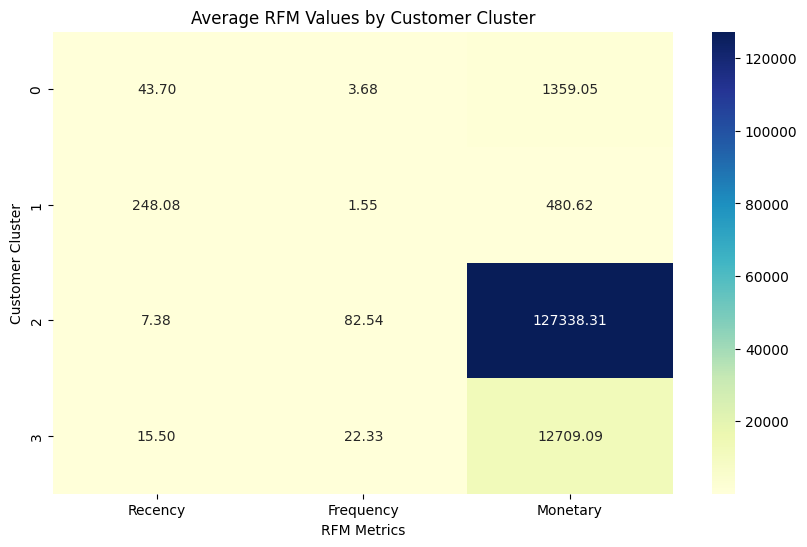

In [57]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_profile[['Recency', 'Frequency', 'Monetary']],
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average RFM Values by Customer Cluster')
plt.xlabel('RFM Metrics')
plt.ylabel('Customer Cluster')

plt.show()

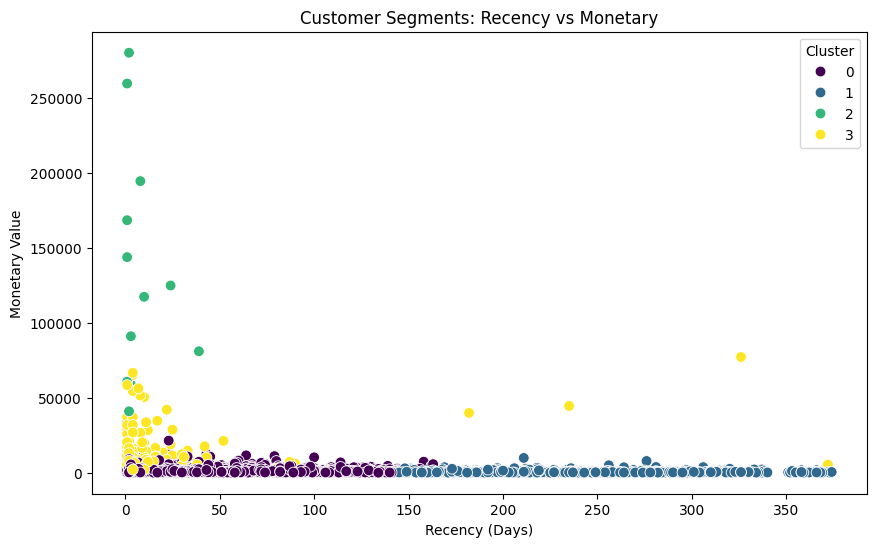

In [58]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')

plt.show()

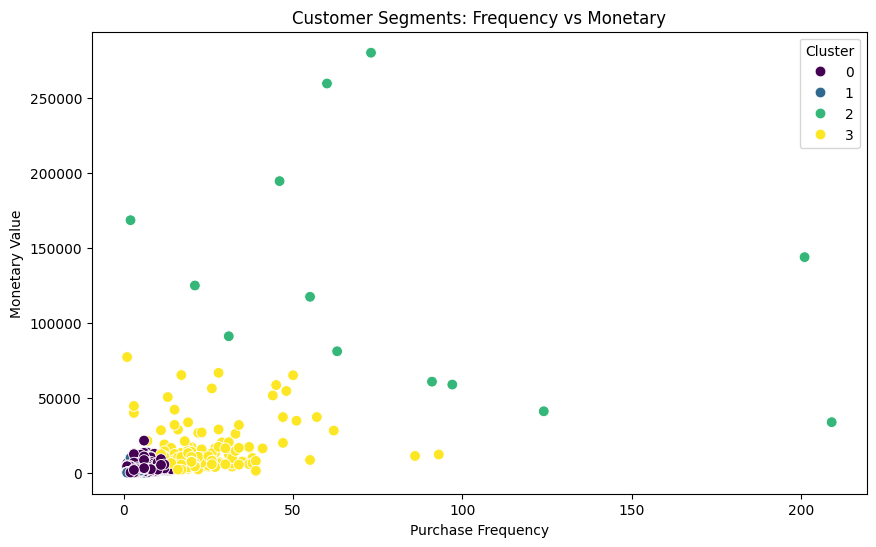

In [59]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')

plt.show()

In [60]:
segment_names = {
    0: 'Regular Customers',
    1: 'Inactive / Low-Value Customers',
    2: 'High-Value Loyal Customers',
    3: 'Loyal Customers'
}

rfm['CustomerSegment'] = rfm['Cluster'].map(segment_names)

rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue,Cluster,CustomerSegment
CustomerID,,,,,,,
12346.0,326,1,77183.60,77183.600000,77183.60,3,Loyal Customers
12347.0,2,7,4310.00,615.714286,4310.00,0,Regular Customers
12348.0,75,4,1797.24,449.310000,1797.24,0,Regular Customers
12349.0,19,1,1757.55,1757.550000,1757.55,0,Regular Customers
12350.0,310,1,334.40,334.400000,334.40,1,Inactive / Low-Value Customers


In [61]:
segment_counts = rfm['CustomerSegment'].value_counts()

segment_counts

,count
CustomerSegment,
Regular Customers,3054
Inactive / Low-Value Customers,1067
Loyal Customers,204
High-Value Loyal Customers,13


In [62]:
segment_summary = rfm.groupby('CustomerSegment')[[
    'Recency',
    'Frequency',
    'Monetary',
    'AveragePurchaseValue',
    'CustomerLifetimeValue'
]].mean().round(2)

segment_summary

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
CustomerSegment,,,,,
High-Value Loyal Customers,7.38,82.54,127338.31,8570.73,127338.31
Inactive / Low-Value Customers,248.08,1.55,480.62,314.81,480.62
Loyal Customers,15.50,22.33,12709.09,1080.41,12709.09
Regular Customers,43.70,3.68,1359.05,376.76,1359.05


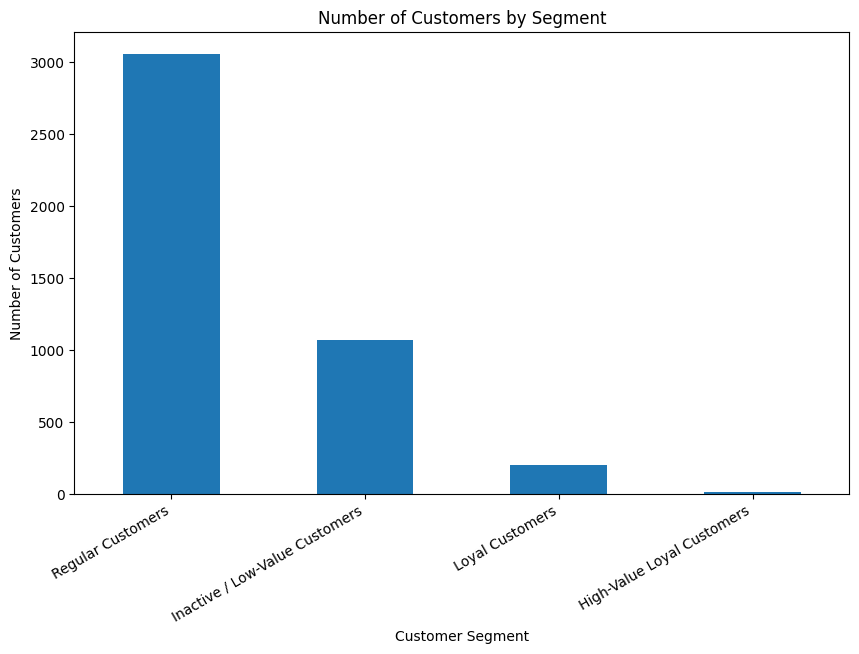

In [63]:
plt.figure(figsize=(10, 6))

segment_counts.plot(kind='bar')

plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')

plt.show()

## Customer Segment Insights

### 1. High-Value Loyal Customers
Cluster 2 represents the most valuable customer group. These customers have very low recency, very high purchase frequency, and very high monetary value. They are highly engaged and contribute significantly to overall revenue.

### 2. Loyal Customers
Cluster 3 consists of customers who purchase recently and relatively frequently, with high spending. These customers show strong engagement and have good potential for long-term retention.

### 3. Regular Customers
Cluster 0 represents customers with moderate recency, frequency, and spending. They are active customers who can potentially be encouraged to purchase more frequently.

### 4. Inactive / Low-Value Customers
Cluster 1 represents customers with high recency, low purchase frequency, and low spending. These customers may require re-engagement campaigns to encourage them to return.

## Marketing Recommendations

| Customer Segment | Recommended Action |
|---|---|
| High-Value Loyal Customers | Provide loyalty rewards, exclusive offers, early access to new products, and personalized recommendations. |
| Loyal Customers | Encourage repeat purchases using personalized offers, loyalty points, and product recommendations. |
| Regular Customers | Use targeted discounts, bundles, and cross-selling offers to increase purchase frequency and spending. |
| Inactive / Low-Value Customers | Use re-engagement emails, limited-time discounts, reminders, and special return offers. |

### Overall Recommendation

The business should use customer segmentation to create targeted marketing campaigns instead of applying the same strategy to every customer. High-value customers should be retained through loyalty programs, while inactive customers should be targeted with re-engagement campaigns.

## Conclusion

The customer segmentation analysis successfully grouped customers based on their purchasing behaviour.

RFM analysis helped identify differences in customer recency, purchase frequency, and spending. K-Means clustering was then used to create meaningful customer segments.

The analysis identified four major customer groups:

- High-Value Loyal Customers
- Loyal Customers
- Regular Customers
- Inactive / Low-Value Customers

Each segment has different business needs. High-value customers should be retained through loyalty programs and personalized offers, while inactive customers can be targeted through re-engagement campaigns.

Overall, customer segmentation can help businesses make better marketing decisions by providing different strategies for different types of customers.

In [64]:
rfm.to_csv('customer_segmentation_analysis.csv', index=True)

print("Customer segmentation file saved successfully.")

Customer segmentation file saved successfully.


In [65]:
import os

print(os.path.exists('customer_segmentation_analysis.csv'))

True


In [66]:
from google.colab import files

files.download('customer_segmentation_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>